In [2]:
import sqlite3
import pandas as pd
import ast
import matplotlib.pyplot as plt

con=sqlite3.connect(r"C:\Users\muhmm\ipl_proj\Data\Raw\ipl.db")
def q(sql):
    return pd.read_sql_query(sql,con)

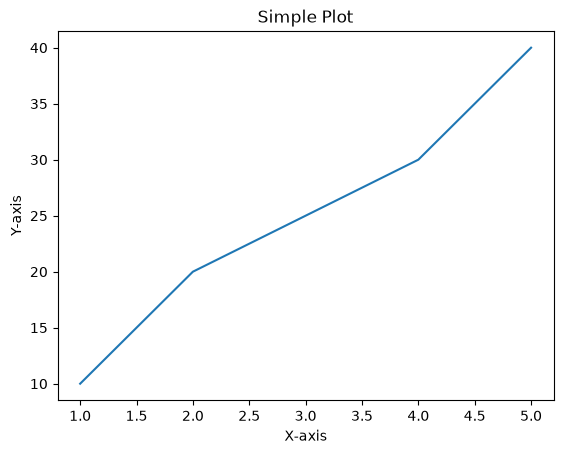

In [3]:
x = [1, 2, 3, 4, 5]
y = [10, 20, 25, 30, 40]

plt.plot(x, y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Simple Plot')
plt.show()

<Axes: title={'center': 'total balls in each phases'}, xlabel='phase', ylabel='total no:of balls'>

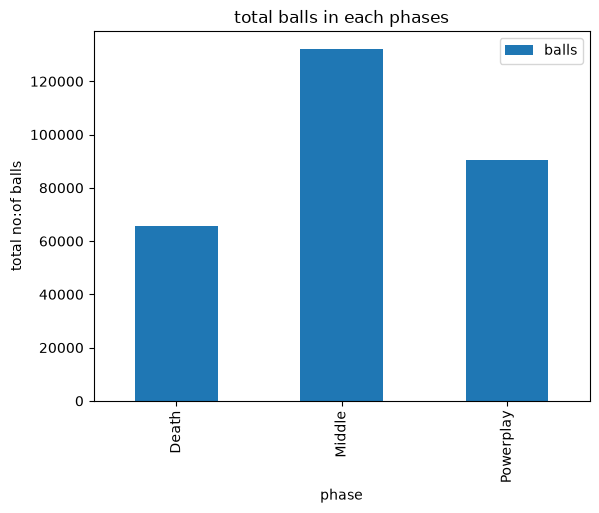

In [4]:
df=pd.read_sql("""select phase , count(*) as balls from v_ball group by phase;""",con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        xlabel="phase",
        ylabel="total no:of balls",
        title="total balls in each phases")

<Axes: title={'center': 'highest six scored batters total sixes'}, xlabel='six score batter', ylabel='scored total_sixes'>

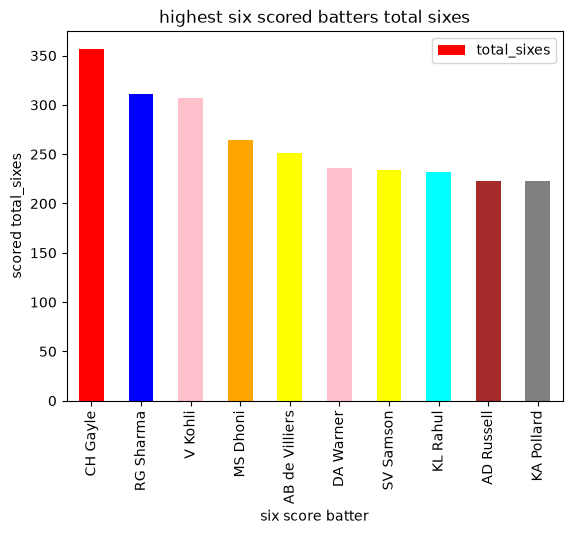

In [5]:
df=pd.read_sql("""
-- list of highest six scores in ipl history

  select batter,
         sum (case when batter_runs=6
              then 1
              else 0
              end)as total_sixes
from v_ball
group by batter
order by total_sixes desc
limit 10;
 """, con)


df.plot(kind="bar",
        x="batter",	
        y="total_sixes",
        xlabel="six score batter",
        ylabel="scored total_sixes",
        color=["red", "blue", "pink", "orange", "yellow",
           "pink", "yellow", "cyan", "brown", "gray"],
        title="highest six scored batters total sixes",

        )

<Axes: title={'center': 'total balls in each phases'}, xlabel='DIIFERENT PHASES of inngs', ylabel='total number of balls'>

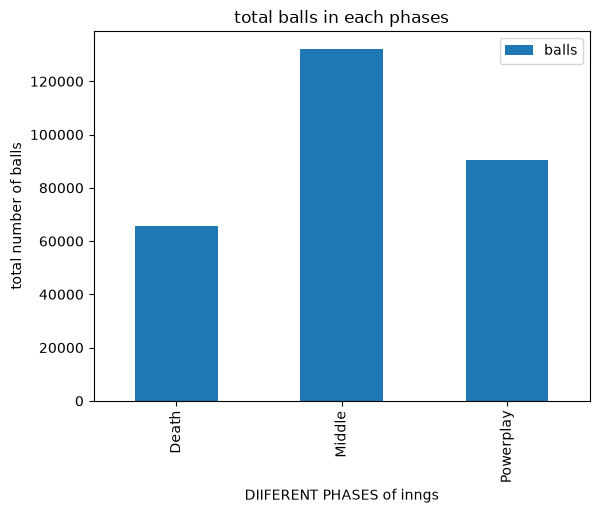

In [6]:
df=pd.read_sql("""SELECT phase, count(*) AS balls FROM v_ball GROUP BY phase;""",con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="total balls in each phases",
        xlabel="DIIFERENT PHASES of inngs",
        ylabel="total number of balls")

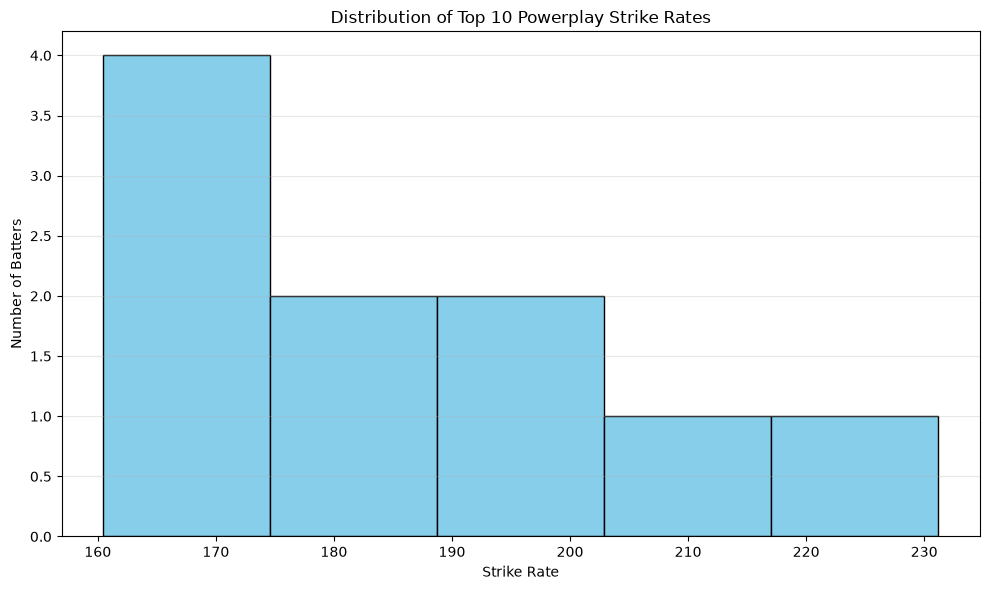

In [7]:
ad = pd.read_sql("""
SELECT 
    batter,
    SUM(batter_runs) AS runs,
    SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) AS balls,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END),
        2
    ) AS strike_rate
FROM v_ball
WHERE phase = 'Powerplay'
GROUP BY batter
HAVING SUM(CASE WHEN is_legal = 1 THEN 1 ELSE 0 END) >= 100
ORDER BY strike_rate DESC
LIMIT 10;
""", con)

plt.figure(figsize=(10, 6))

plt.hist(
    ad["strike_rate"],
    bins=5,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Top 10 Powerplay Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Number of Batters")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

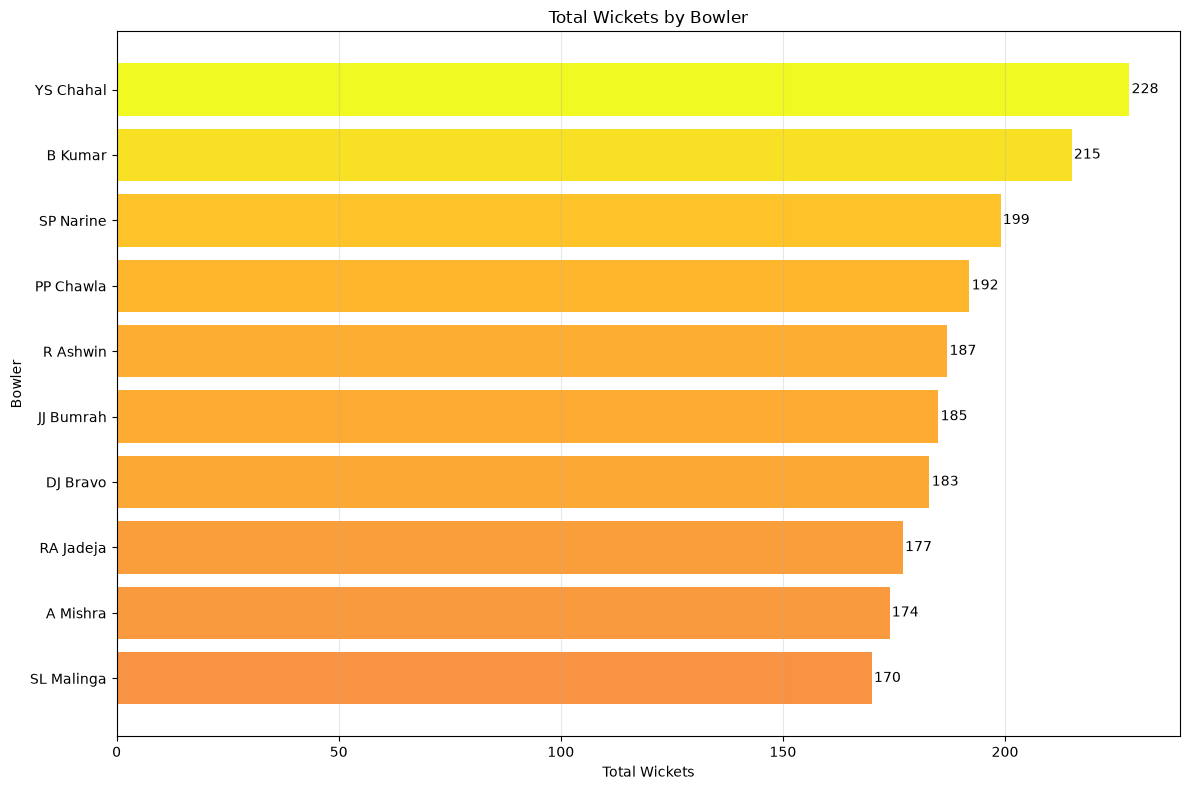

In [10]:
af= pd.read_sql("""
SELECT 
    bowler,
    SUM(bowler_wicket) AS wicket
FROM v_ball
GROUP BY bowler
ORDER BY wicket DESC
limit 10;
""", con)

plt.figure(figsize=(12, 8))

colors = plt.cm.plasma(
    af["wicket"] / af["wicket"].max()
)

bars = plt.barh(
    af["bowler"],
    af["wicket"],
    color=colors
)

plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.title("Total Wickets by Bowler")

plt.gca().invert_yaxis()

# Add wicket values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

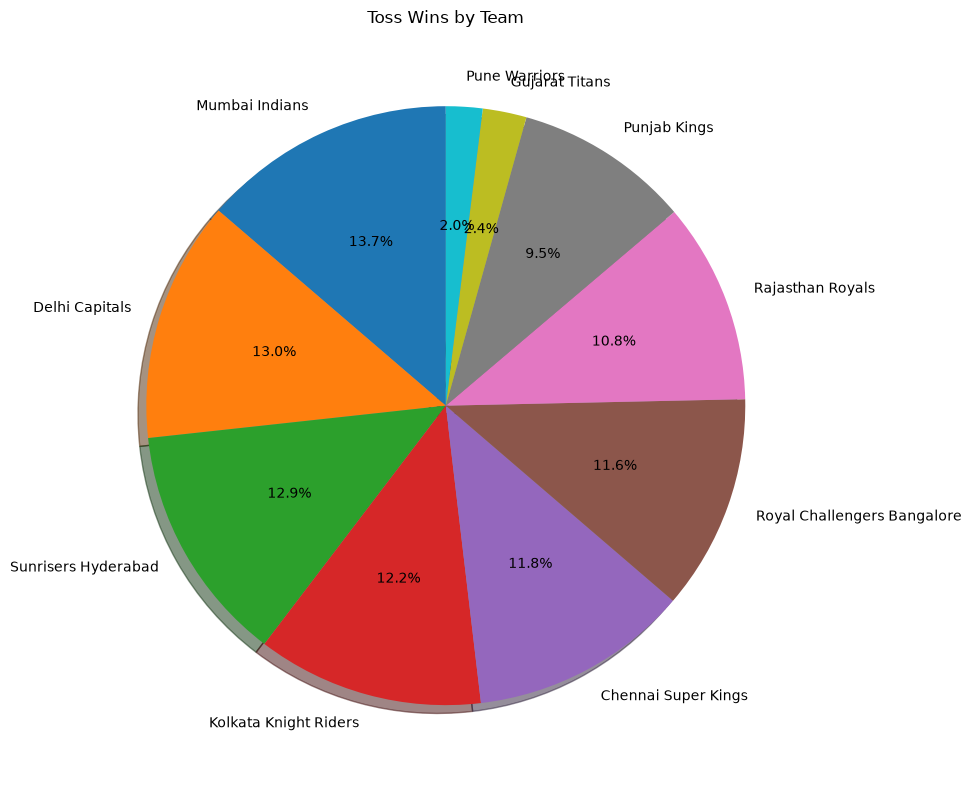

In [12]:
ag = pd.read_sql("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC
limit 10;
""", con)

plt.figure(figsize=(10, 8))

plt.pie(
    ag["toss_won"],
    labels=ag["toss_winner"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Toss Wins by Team")

plt.tight_layout()
plt.show()